In [71]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_bounds
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


In [72]:
from pathlib import Path

# ── Root path ─────────────────────────────
ROOT = Path("/scratch3/plant-traits-v2/data")

PATHS = {
    "gbif": ROOT / "22km" / "gbif",
    "splot": ROOT / "22km" / "splot",
    "merged": ROOT / "22km" / "merged",
}

GBIF_DIR   = PATHS["gbif"]
SPLOT_DIR  = PATHS["splot"]
MERGED_DIR = PATHS["merged"]
MASK_DIR   = MERGED_DIR / "source_mask"

# Create output directories
MERGED_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

# ── Collect trait files ───────────────────
gbif_files  = sorted(GBIF_DIR.glob("*.tif"))
splot_files = sorted(SPLOT_DIR.glob("*.tif"))

# Build lookup dict: trait_id -> path
gbif_dict  = {f.stem: f for f in gbif_files}
splot_dict = {f.stem: f for f in splot_files}

# Traits present in either/both sources
all_traits = sorted(set(gbif_dict) | set(splot_dict))
common_traits = sorted(set(gbif_dict) & set(splot_dict))

# ── Print summary ─────────────────────────
print(f"GBIF traits:   {len(gbif_dict)}")
print(f"sPlot traits:  {len(splot_dict)}")
print(f"Common traits: {len(common_traits)}")
print(f"Union traits:  {len(all_traits)}")

print(f"\nOutput directory: {MERGED_DIR}")

GBIF traits:   37
sPlot traits:  37
Common traits: 37
Union traits:  37

Output directory: /scratch3/plant-traits-v2/data/22km/merged


In [73]:
def load_tif(path):
    """
    Load a multi-band GeoTIFF as a float32 array.
    Nodata values are converted to NaN.
    Returns (array, profile).
    """
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)  # Read all bands
        nodata = src.nodata
        profile = src.profile.copy()
    if nodata is not None:
        data[data == nodata] = np.nan
    return data, profile


def merge_splot_priority(gbif_arr, splot_arr):
    """
    Pixel-wise merge: sPlot takes priority over GBIF.
    Handles multi-band arrays.

    Returns
    -------
    merged : np.ndarray  (float32, shape like input)
        Merged values.
    source : np.ndarray  (uint8, same spatial shape)
        Source mask:
            0 = no data from either source
            1 = GBIF only (sPlot was NaN)
            2 = sPlot (priority; GBIF may also be valid here)
    """
    if gbif_arr.ndim == 2:
        gbif_arr = gbif_arr[np.newaxis, ...]
    if splot_arr.ndim == 2:
        splot_arr = splot_arr[np.newaxis, ...]
    
    n_bands = gbif_arr.shape[0]
    h, w = gbif_arr.shape[1:]
    
    merged = np.full((n_bands, h, w), np.nan, dtype=np.float32)
    source_temp = np.zeros((n_bands, h, w), dtype=np.uint8)

    for band in range(n_bands):
        gbif_band = gbif_arr[band]
        splot_band = splot_arr[band]
        
        gbif_valid  = ~np.isnan(gbif_band)
        splot_valid = ~np.isnan(splot_band)

        # Step 1: fill with GBIF where available
        merged[band][gbif_valid] = gbif_band[gbif_valid]
        source_temp[band][gbif_valid] = 1

        # Step 2: overwrite with sPlot wherever sPlot is valid (priority)
        merged[band][splot_valid] = splot_band[splot_valid]
        source_temp[band][splot_valid] = 2

    # Compute source mask based on any band having data
    gbif_valid_any = np.any(~np.isnan(gbif_arr), axis=0)
    splot_valid_any = np.any(~np.isnan(splot_arr), axis=0)
    
    source = np.zeros((h, w), dtype=np.uint8)
    source[gbif_valid_any] = 1
    source[splot_valid_any] = 2

    return merged, source


def save_tif(array, profile, out_path, dtype=None, nodata=np.nan):
    """
    Save array as a multi-band GeoTIFF.
    """
    if array.ndim == 2:
        array = array[np.newaxis, ...]
    n_bands = array.shape[0]
    
    out_profile = profile.copy()
    out_profile.update({
        'count':   n_bands,
        'dtype':   dtype or str(array.dtype),
        'nodata':  nodata,
        'compress': 'lzw',
        'tiled':   True,
    })
    with rasterio.open(out_path, 'w', **out_profile) as dst:
        for band in range(1, n_bands + 1):
            dst.write(array[band-1], band)


print('Helper functions defined.')

Helper functions defined.


In [74]:
summary_rows = []

for trait in all_traits:

    has_gbif  = trait in gbif_dict
    has_splot = trait in splot_dict

    # ── Load arrays ──────────────────────────────────────────────────────────
    if has_gbif:
        gbif_arr, profile = load_tif(gbif_dict[trait])
        n_bands = gbif_arr.shape[0]
    else:
        # If GBIF is missing, load sPlot just to get the profile + shape
        _, profile = load_tif(splot_dict[trait])
        n_bands = profile['count']
        gbif_arr = np.full((n_bands, profile['height'], profile['width']), np.nan, dtype=np.float32)

    if has_splot:
        splot_arr, _ = load_tif(splot_dict[trait])
    else:
        splot_arr = np.full_like(gbif_arr, np.nan, dtype=np.float32)

    # ── Merge ─────────────────────────────────────────────────────────────────
    merged, source = merge_splot_priority(gbif_arr, splot_arr)

    # ── Save merged TIF ───────────────────────────────────────────────────────
    save_tif(merged, profile, MERGED_DIR / f"{trait}.tif", dtype="float32")

    # ── Save source mask TIF ─────────────────────────────────────────────────
    save_tif(
        source,
        profile,
        MASK_DIR / f"{trait}_source.tif",
        dtype="uint8",
        nodata=255
    )

    # ── Compute per-trait stats ───────────────────────────────────────────────
    n_gbif_only   = int(np.sum(source == 1))
    n_splot       = int(np.sum(source == 2))
    n_total_valid = n_gbif_only + n_splot
    n_nan         = int(np.sum(source == 0))

    # Pixels where BOTH sources had data (in at least one band)
    n_both = int(np.sum(np.any(~np.isnan(gbif_arr), axis=0) & np.any(~np.isnan(splot_arr), axis=0)))

    summary_rows.append({
        "trait":           trait,
        "has_gbif":        has_gbif,
        "has_splot":       has_splot,
        "n_gbif_only":     n_gbif_only,
        "n_splot":         n_splot,
        "n_both_sources":  n_both,
        "n_total_valid":   n_total_valid,
        "n_no_data":       n_nan,
        "pct_splot":       round(100 * n_splot / n_total_valid, 1) if n_total_valid > 0 else 0,
        "pct_gbif_only":   round(100 * n_gbif_only / n_total_valid, 1) if n_total_valid > 0 else 0,
    })

    print(
        f"{trait:30s}  total={n_total_valid:6d}  "
        f"sPlot={n_splot:6d}  GBIF-only={n_gbif_only:6d}  "
        f"overlap={n_both:6d}  NaN={n_nan:6d}"
    )

summary_df = pd.DataFrame(summary_rows)

# ── Save summary ─────────────────────────────────────────────────────────────
summary_path = ROOT / "22km" / "merge_summary.csv"
summary_df.to_csv(summary_path, index=False)

print(f"\nSaved: {summary_path}")

X1080                           total=131792  sPlot= 33078  GBIF-only= 98714  overlap= 28522  NaN=922312
X13                             total=131621  sPlot= 33078  GBIF-only= 98543  overlap= 28495  NaN=922483
X138                            total=131987  sPlot= 33078  GBIF-only= 98909  overlap= 28502  NaN=922117
X14                             total=131680  sPlot= 33078  GBIF-only= 98602  overlap= 28498  NaN=922424
X144                            total=132336  sPlot= 33078  GBIF-only= 99258  overlap= 28533  NaN=921768
X145                            total=132593  sPlot= 33078  GBIF-only= 99515  overlap= 28548  NaN=921511
X146                            total=131892  sPlot= 33078  GBIF-only= 98814  overlap= 28503  NaN=922212
X15                             total=131431  sPlot= 33078  GBIF-only= 98353  overlap= 28474  NaN=922673
X163                            total=131863  sPlot= 33078  GBIF-only= 98785  overlap= 28492  NaN=922241
X169                            total=130786  sPlot= 33

In [75]:
print('=== Merge Summary ===')
print(f'Traits processed:  {len(summary_df)}')
print(f'Traits with GBIF:  {summary_df.has_gbif.sum()}')
print(f'Traits with sPlot: {summary_df.has_splot.sum()}')
print()
print(summary_df[[
    'trait', 'n_splot', 'n_gbif_only', 'n_both_sources',
    'n_total_valid', 'pct_splot', 'pct_gbif_only'
]].to_string(index=False))

print()
print('=== Aggregate across all traits ===')
print(f'Mean sPlot pixels per trait:     {summary_df.n_splot.mean():.0f}')
print(f'Mean GBIF-only pixels per trait: {summary_df.n_gbif_only.mean():.0f}')
print(f'Mean overlap pixels per trait:   {summary_df.n_both_sources.mean():.0f}')
print(f'Mean % from sPlot:               {summary_df.pct_splot.mean():.1f}%')

=== Merge Summary ===
Traits processed:  37
Traits with GBIF:  37
Traits with sPlot: 37

trait  n_splot  n_gbif_only  n_both_sources  n_total_valid  pct_splot  pct_gbif_only
X1080    33078        98714           28522         131792       25.1           74.9
  X13    33078        98543           28495         131621       25.1           74.9
 X138    33078        98909           28502         131987       25.1           74.9
  X14    33078        98602           28498         131680       25.1           74.9
 X144    33078        99258           28533         132336       25.0           75.0
 X145    33078        99515           28548         132593       24.9           75.1
 X146    33078        98814           28503         131892       25.1           74.9
  X15    33078        98353           28474         131431       25.2           74.8
 X163    33078        98785           28492         131863       25.1           74.9
 X169    33078        97708           28432         130786   

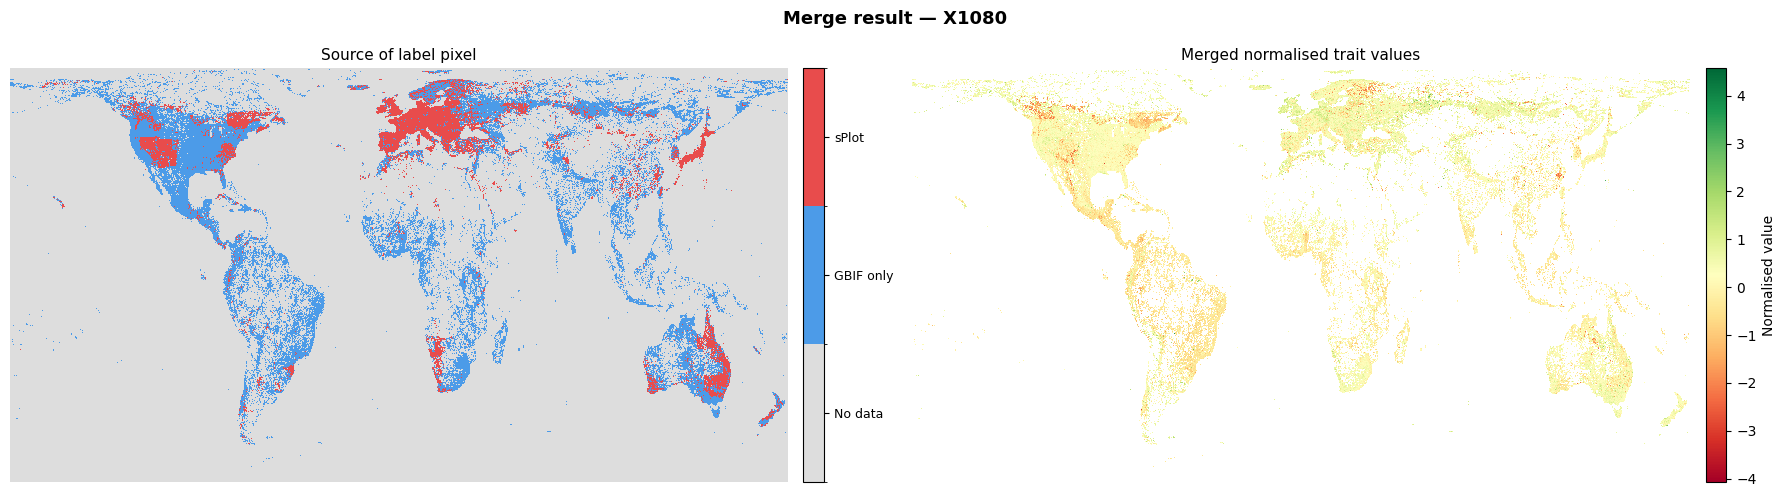

Saved: merge_coverage_X1080.png


In [76]:
# Pick the first trait as an example — change this to any trait ID
example_trait = all_traits[0]

# Load the source mask
with rasterio.open(MASK_DIR / f'{example_trait}_source.tif') as src:
    source_map = src.read(1).astype(float)
    source_map[source_map == 255] = np.nan  # nodata

# Load merged values
with rasterio.open(MERGED_DIR / f'{example_trait}.tif') as src:
    merged_map = src.read(1).astype(np.float32)
    merged_map[merged_map == src.nodata] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(f'Merge result — {example_trait}', fontsize=13, fontweight='bold')

# ── Source map ───────────────────────────────────────────────────────────────
cmap_src = mcolors.ListedColormap(['#DDDDDD', '#4C9BE8', '#E84C4C'])
bounds_src = [-0.5, 0.5, 1.5, 2.5]
norm_src = mcolors.BoundaryNorm(bounds_src, cmap_src.N)

im0 = axes[0].imshow(source_map, cmap=cmap_src, norm=norm_src,
                      interpolation='nearest', aspect='auto')
cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.02,
                     ticks=[0, 1, 2])
cbar0.ax.set_yticklabels(['No data', 'GBIF only', 'sPlot'], fontsize=9)
axes[0].set_title('Source of label pixel', fontsize=11)
axes[0].axis('off')

# ── Merged values ────────────────────────────────────────────────────────────
im1 = axes[1].imshow(merged_map, cmap='RdYlGn',
                      interpolation='nearest', aspect='auto')
plt.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.02, label='Normalised value')
axes[1].set_title(f'Merged normalised trait values', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(ROOT / f'merge_coverage_{example_trait}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: merge_coverage_{example_trait}.png')

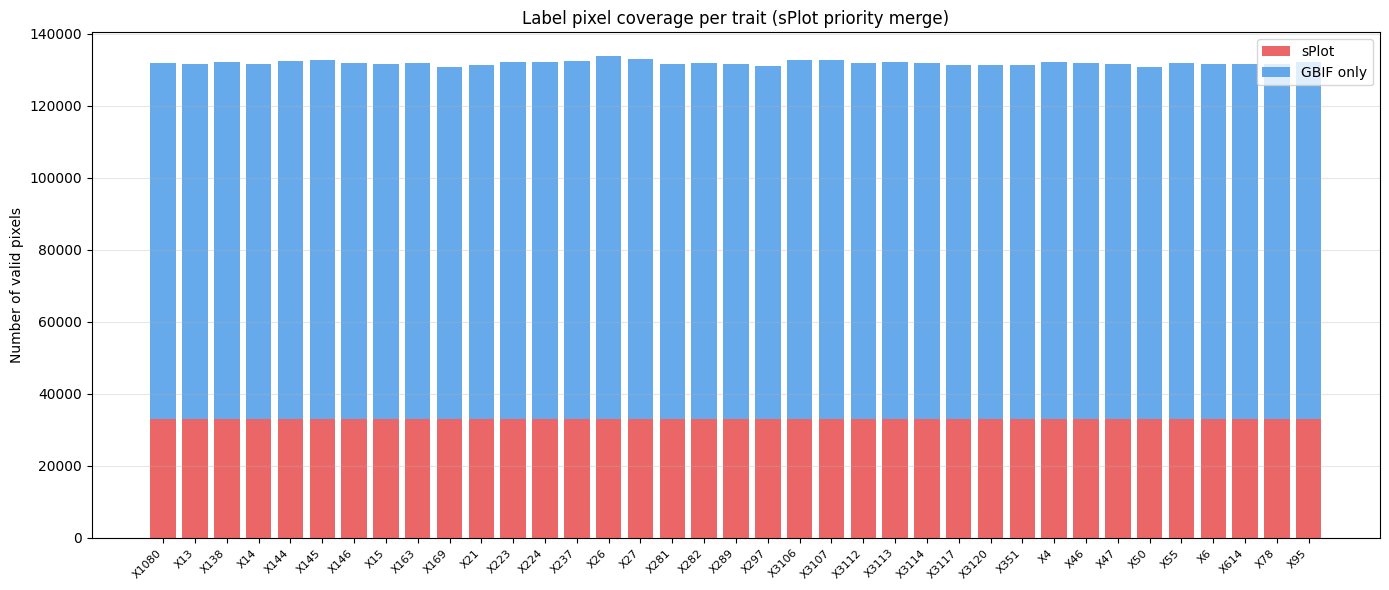

Saved: merge_coverage_barchart.png


In [77]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(summary_df))
ax.bar(x, summary_df['n_splot'],    label='sPlot',     color='#E84C4C', alpha=0.85)
ax.bar(x, summary_df['n_gbif_only'], label='GBIF only', color='#4C9BE8', alpha=0.85,
       bottom=summary_df['n_splot'])

ax.set_xticks(x)
ax.set_xticklabels(summary_df['trait'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of valid pixels')
ax.set_title('Label pixel coverage per trait (sPlot priority merge)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'merge_coverage_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: merge_coverage_barchart.png')

In [78]:
SKCV_DIR = ROOT / "22km" / "skcv_splits"

fold_summary_rows = []

print("SKCV_DIR:", SKCV_DIR)
print("Exists:", SKCV_DIR.exists())
print("Parquet files:", len(list(SKCV_DIR.glob("*.parquet"))))

for trait in all_traits:
    parquet_path = SKCV_DIR / f"{trait}_mean.parquet"
    if not parquet_path.exists():
        print(f'  WARNING: no skcv parquet for {trait}, skipping.')
        continue

    splits_df = pd.read_parquet(parquet_path)  # columns: x, y, fold

    # Load the source mask to find which pixels are sPlot (source == 2)
    with rasterio.open(MASK_DIR / f'{trait}_source.tif') as src:
        source_map = src.read(1)  # uint8: 0=NaN, 1=GBIF, 2=sPlot
        transform  = src.transform
        crs        = src.crs

    # Map each pixel in splits_df to a row/col index, then look up its source
    # The parquet stores x,y in the raster CRS
    cols = ((splits_df['x'] - transform.c) / transform.a).astype(int)
    rows = ((splits_df['y'] - transform.f) / transform.e).astype(int)

    # Clip to valid range (safety)
    h, w = source_map.shape
    valid_idx = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
    splits_df = splits_df[valid_idx].copy()
    rows = rows[valid_idx]
    cols = cols[valid_idx]

    splits_df['source'] = source_map[rows, cols]
    splot_splits = splits_df[splits_df['source'] == 2]

    fold_counts = splot_splits.groupby('fold').size()
    row = {'trait': trait, 'total_splot_in_folds': len(splot_splits)}
    for fold_id in range(5):
        row[f'fold_{fold_id}'] = int(fold_counts.get(fold_id, 0))
    fold_summary_rows.append(row)

fold_df = pd.DataFrame(fold_summary_rows)
fold_df.to_csv(ROOT / "22km" / "splot_pixels_per_fold.csv", index=False)

print('sPlot validation pixels per fold (per trait):')
print(fold_df.to_string(index=False))
print(f'\nSaved: splot_pixels_per_fold.csv')

SKCV_DIR: /scratch3/plant-traits-v2/data/22km/skcv_splits
Exists: True
Parquet files: 37
sPlot validation pixels per fold (per trait):
trait  total_splot_in_folds  fold_0  fold_1  fold_2  fold_3  fold_4
X1080                 31813    6060    7839    7853    5491    4570
  X13                 31686    6505    5160    5221    8245    6555
 X138                 31649    5258    9168    5017    8581    3625
  X14                 31887    9904    4423    5675    7116    4769
 X144                 32060   10436    7231    4032    4276    6085
 X145                 31974    3738   12562    6752    5479    3443
 X146                 31908    7773    6031    7501    6816    3787
  X15                 31821    4133    8663    5084   11166    2775
 X163                 31870    2561    5521    1076   16697    6015
 X169                 31589    3330    5476    5431   12783    4569
  X21                 31597    3374    4969    9281    8369    5604
 X223                 31784    7193    4376    51

In [79]:
print('Running sanity checks on all merged files...\n')
all_passed = True

for trait in all_traits:
    merged_path = MERGED_DIR / f'{trait}.tif'
    mask_path   = MASK_DIR   / f'{trait}_source.tif'

    with rasterio.open(merged_path) as src:
        merged = src.read().astype(np.float32)  # Read all bands
        merged[merged == src.nodata] = np.nan

    with rasterio.open(mask_path) as src:
        source = src.read(1)

    # Check 1: no unexpected source values
    unique_sources = set(np.unique(source[source != 255]))
    check1 = unique_sources.issubset({0, 1, 2})

    # Check 2: merged NaN in all bands ↔ source == 0
    merged_all_nan = np.all(np.isnan(merged), axis=0)
    source_zero = (source == 0)
    check2 = np.all(merged_all_nan == source_zero)

    # Check 3: normalised values roughly in [-100, 100] (very loose — catches unit errors)
    valid_vals = merged[~np.isnan(merged)].ravel()
    check3 = (valid_vals.min() > -1000) and (valid_vals.max() < 1000) if len(valid_vals) > 0 else True

    status = 'PASS' if (check1 and check2 and check3) else 'FAIL'
    if status == 'FAIL':
        all_passed = False
    print(f'  {trait:30s}  source_vals={check1}  nan_consistent={check2}  value_range={check3}  → {status}')

print()
if all_passed:
    print('All checks PASSED.')
else:
    print('Some checks FAILED — review output above.')

Running sanity checks on all merged files...

  X1080                           source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X13                             source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X138                            source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X14                             source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X144                            source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X145                            source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X146                            source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X15                             source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X163                            source_vals=True  nan_consistent=True  value_range=False  → FAIL
  X169                            source_vals=True  nan_consist

In [80]:
# ── Root path ─────────────────────────────
ROOT = Path("/scratch3/plant-traits-v2/data")

PATHS = {
    "gbif":   ROOT / "22km" / "gbif",
    "splot":  ROOT / "22km" / "splot",
    "merged": ROOT / "22km" / "merged",
    "skcv":   ROOT / "22km" / "skcv_splits",
    "figs":   ROOT / "22km" / "figures",
}

GBIF_DIR   = PATHS["gbif"]
SPLOT_DIR  = PATHS["splot"]
MERGED_DIR = PATHS["merged"]
MASK_DIR   = MERGED_DIR / "source_mask"
SKCV_DIR   = PATHS["skcv"]
FIG_DIR    = PATHS["figs"]

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Collect trait files ───────────────────
gbif_files  = sorted(GBIF_DIR.glob("*.tif"))
splot_files = sorted(SPLOT_DIR.glob("*.tif"))

gbif_dict  = {f.stem: f for f in gbif_files}
splot_dict = {f.stem: f for f in splot_files}

all_traits    = sorted(set(gbif_dict) | set(splot_dict))
common_traits = sorted(set(gbif_dict) & set(splot_dict))

print(f"GBIF traits:   {len(gbif_dict)}")
print(f"sPlot traits:  {len(splot_dict)}")
print(f"Common traits: {len(common_traits)}")
print(f"Union traits:  {len(all_traits)}")
print(f"\nFigures will be saved to: {FIG_DIR}")

GBIF traits:   37
sPlot traits:  37
Common traits: 37
Union traits:  37

Figures will be saved to: /scratch3/plant-traits-v2/data/22km/figures


In [81]:
def load_tif(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
    if nodata is not None:
        data[data == nodata] = np.nan
    return data


def load_source_mask(trait):
    """Load source mask as float with NaN for nodata."""
    with rasterio.open(MASK_DIR / f'{trait}_source.tif') as src:
        data = src.read(1).astype(float)
        data[data == 255] = np.nan
    return data


# Consistent colour scheme used throughout
SOURCE_CMAP   = mcolors.ListedColormap(['#EEEEEE', '#4C9BE8', '#E84C4C'])
SOURCE_NORM   = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], SOURCE_CMAP.N)
SOURCE_LABELS = ['No data', 'GBIF only', 'sPlot']
SOURCE_COLORS = ['#EEEEEE', '#4C9BE8', '#E84C4C']

FOLD_CMAP = plt.cm.get_cmap('tab10', 5)

print('Helpers ready.')

Helpers ready.


In [82]:
# ── Load summary CSVs produced by 01b ────────────────────────────────────────
summary_df = pd.read_csv(ROOT / "22km" / "merge_summary.csv")
fold_df    = pd.read_csv(ROOT / "22km" / "splot_pixels_per_fold.csv")

print(f"merge_summary.csv      : {len(summary_df)} rows")
print(f"splot_pixels_per_fold  : {len(fold_df)} rows")
print(f"Columns in summary_df  : {list(summary_df.columns)}")

# ── Helper functions ──────────────────────────────────────────────────────────
def load_tif(path):
    """Load single-band GeoTIFF as float32 array with NaN for nodata."""
    with rasterio.open(path) as src:
        data   = src.read(1).astype(np.float32)
        nodata = src.nodata
    if nodata is not None:
        data[data == nodata] = np.nan
    return data


def load_source_mask(trait):
    """Load source mask (uint8) as float with NaN for nodata (255)."""
    with rasterio.open(MASK_DIR / f"{trait}_source.tif") as src:
        data = src.read(1).astype(float)
        data[data == 255] = np.nan
    return data


# ── Consistent colour scheme ──────────────────────────────────────────────────
SOURCE_CMAP   = mcolors.ListedColormap(["#EEEEEE", "#4C9BE8", "#E84C4C"])
SOURCE_NORM   = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], SOURCE_CMAP.N)
SOURCE_LABELS = ["No data", "GBIF only", "sPlot"]
SOURCE_COLORS = ["#EEEEEE", "#4C9BE8", "#E84C4C"]

print("Helpers ready.")

merge_summary.csv      : 37 rows
splot_pixels_per_fold  : 37 rows
Columns in summary_df  : ['trait', 'has_gbif', 'has_splot', 'n_gbif_only', 'n_splot', 'n_both_sources', 'n_total_valid', 'n_no_data', 'pct_splot', 'pct_gbif_only']
Helpers ready.


Aggregating source masks across all traits...


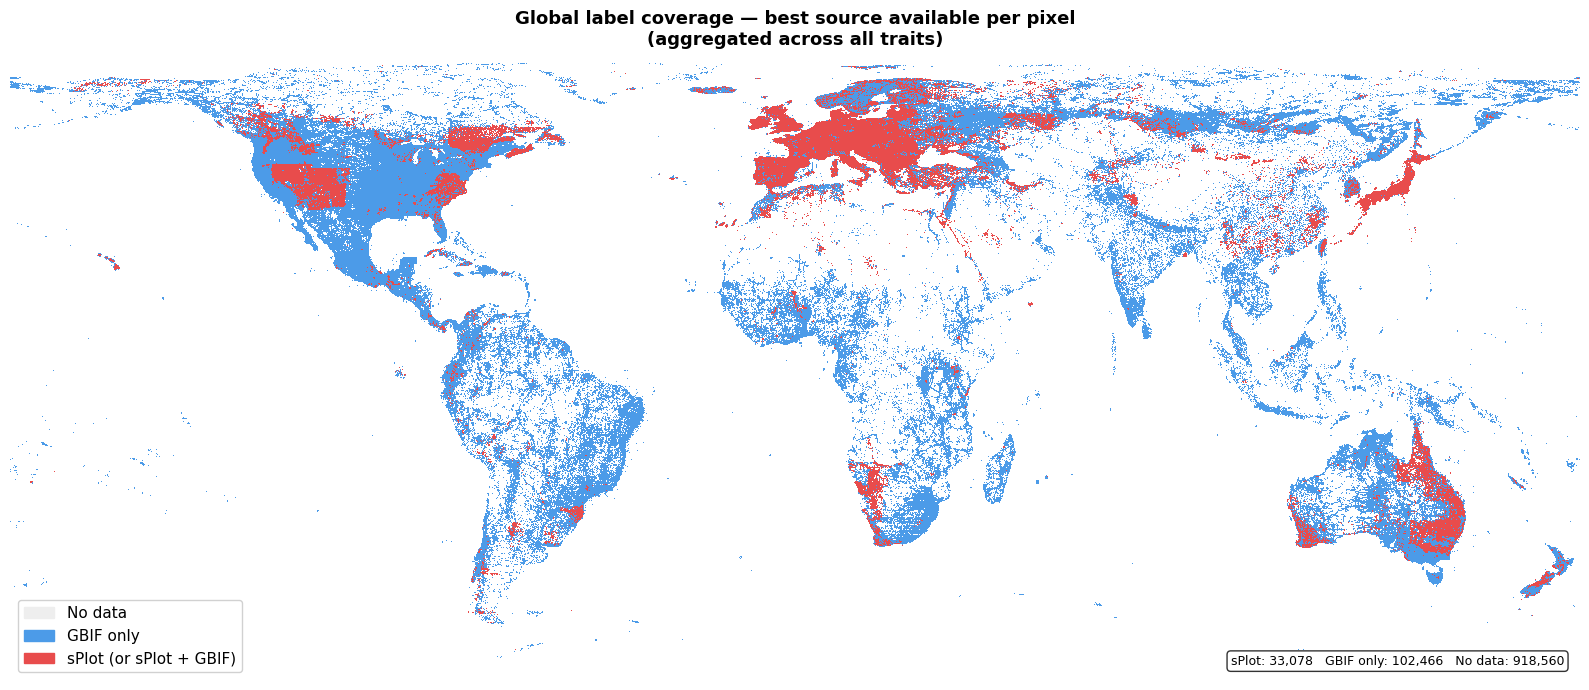

Saved: fig1_global_source_coverage.png


In [83]:
print("Aggregating source masks across all traits...")
agg_source = None

for trait in all_traits:
    mask_path = MASK_DIR / f"{trait}_source.tif"
    if not mask_path.exists():
        print(f"  WARNING: missing mask for {trait}, skipping.")
        continue
    src_arr   = load_source_mask(trait)
    src_clean = np.where(np.isnan(src_arr), 0, src_arr)
    agg_source = src_clean if agg_source is None else np.maximum(agg_source, src_clean)

agg_source = agg_source.astype(float)
agg_source[agg_source == 0] = np.nan

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor("white")

ax.imshow(agg_source, cmap=SOURCE_CMAP, norm=SOURCE_NORM,
          interpolation="nearest", aspect="auto")

patches = [
    mpatches.Patch(color="#EEEEEE", label="No data"),
    mpatches.Patch(color="#4C9BE8", label="GBIF only"),
    mpatches.Patch(color="#E84C4C", label="sPlot (or sPlot + GBIF)"),
]
ax.legend(handles=patches, loc="lower left", fontsize=11, framealpha=0.9)
ax.set_title("Global label coverage — best source available per pixel\n"
             "(aggregated across all traits)",
             fontsize=13, fontweight="bold", pad=12)
ax.axis("off")

n_splot  = int(np.sum(agg_source == 2))
n_gbif   = int(np.sum(agg_source == 1))
n_nodata = int(np.sum(np.isnan(agg_source)))
ax.text(0.99, 0.02,
        f"sPlot: {n_splot:,}   GBIF only: {n_gbif:,}   No data: {n_nodata:,}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_global_source_coverage.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig1_global_source_coverage.png")

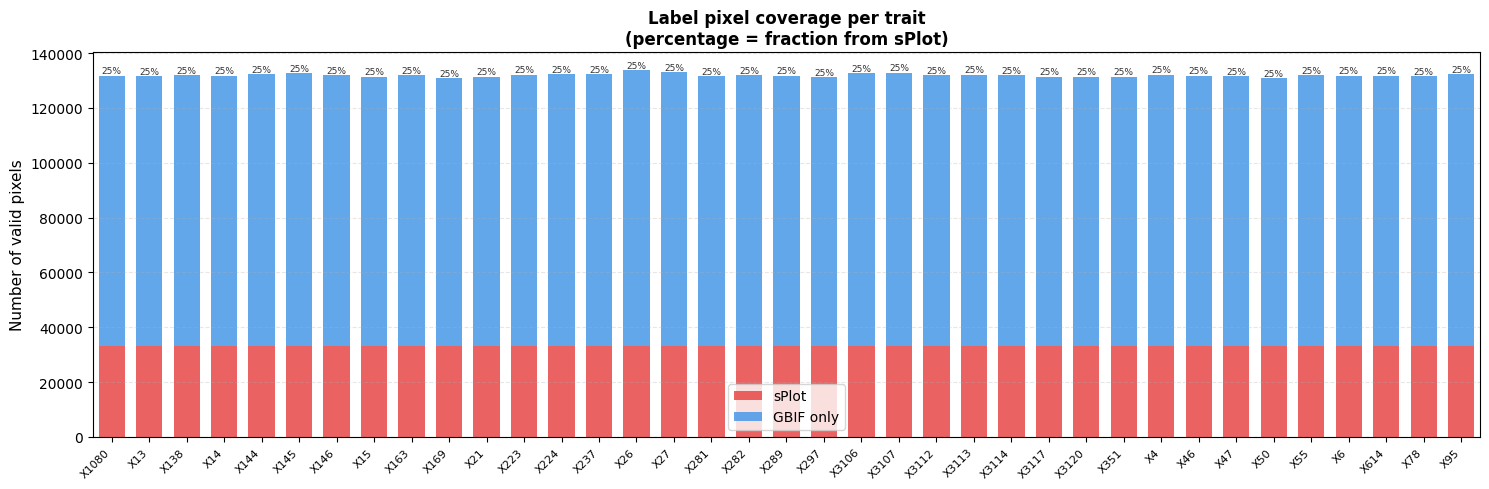

Saved: fig2_coverage_per_trait.png


In [84]:
fig, ax = plt.subplots(figsize=(15, 5))

x = np.arange(len(summary_df))
ax.bar(x, summary_df["n_splot"],
       label="sPlot",     color="#E84C4C", alpha=0.88, width=0.7)
ax.bar(x, summary_df["n_gbif_only"],
       label="GBIF only", color="#4C9BE8", alpha=0.88, width=0.7,
       bottom=summary_df["n_splot"])

for i, row in summary_df.iterrows():
    total = row["n_total_valid"]
    if total > 0:
        ax.text(i, total + 200, f"{row['pct_splot']:.0f}%",
                ha="center", va="bottom", fontsize=6.5, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(summary_df["trait"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Number of valid pixels", fontsize=11)
ax.set_title("Label pixel coverage per trait\n"
             "(percentage = fraction from sPlot)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_xlim(-0.5, len(x) - 0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_coverage_per_trait.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig2_coverage_per_trait.png")

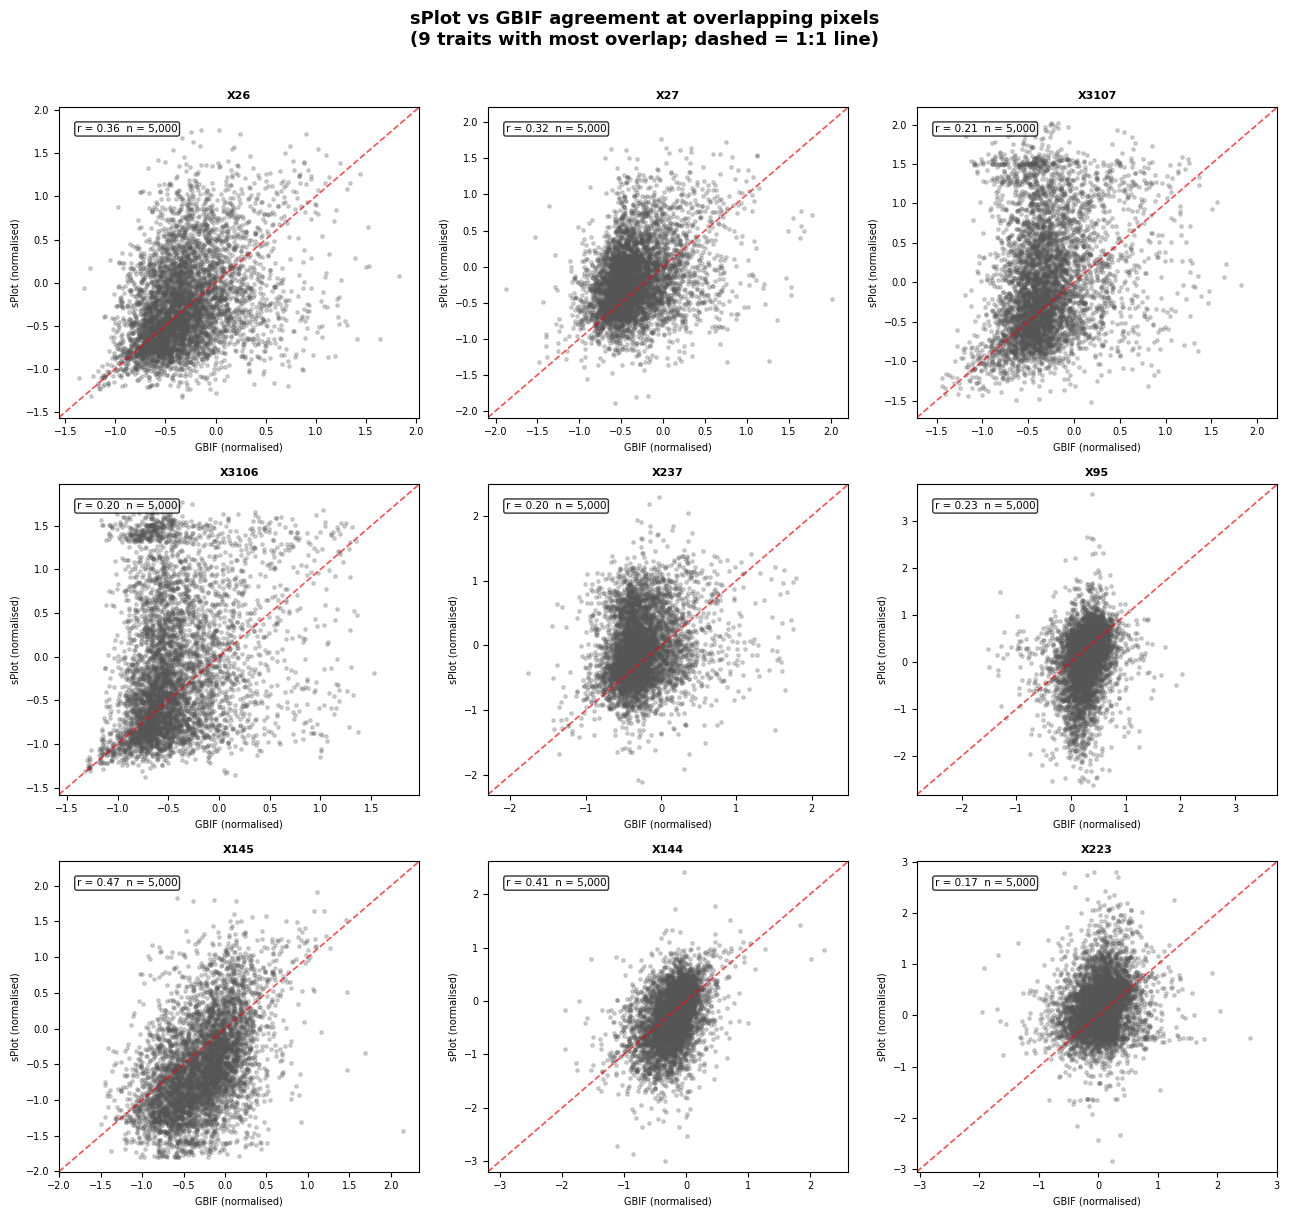

Saved: fig3_splot_vs_gbif_agreement.png


In [85]:
top_overlap = summary_df.nlargest(9, "n_both_sources")["trait"].tolist()

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
fig.suptitle("sPlot vs GBIF agreement at overlapping pixels\n"
             "(9 traits with most overlap; dashed = 1:1 line)",
             fontsize=13, fontweight="bold", y=1.01)

for ax, trait in zip(axes.flat, top_overlap):
    gbif_path  = GBIF_DIR  / f"{trait}.tif"
    splot_path = SPLOT_DIR / f"{trait}.tif"
    if not gbif_path.exists() or not splot_path.exists():
        ax.set_visible(False)
        continue

    g    = load_tif(gbif_path)
    s    = load_tif(splot_path)
    mask = ~np.isnan(g) & ~np.isnan(s)
    g, s = g[mask].ravel(), s[mask].ravel()

    if len(g) < 10:
        ax.set_visible(False)
        continue

    if len(g) > 5000:
        idx = np.random.choice(len(g), 5000, replace=False)
        g, s = g[idx], s[idx]

    r, _ = stats.pearsonr(g, s)
    ax.scatter(g, s, alpha=0.25, s=6, color="#555555", rasterized=True)

    lim = [min(g.min(), s.min()) - 0.2, max(g.max(), s.max()) + 0.2]
    ax.plot(lim, lim, "r--", linewidth=1.2, alpha=0.7)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(trait, fontsize=8, fontweight="bold")
    ax.set_xlabel("GBIF (normalised)", fontsize=7)
    ax.set_ylabel("sPlot (normalised)", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.text(0.05, 0.92, f"r = {r:.2f}  n = {len(g):,}",
            transform=ax.transAxes, fontsize=7.5,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_splot_vs_gbif_agreement.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig3_splot_vs_gbif_agreement.png")

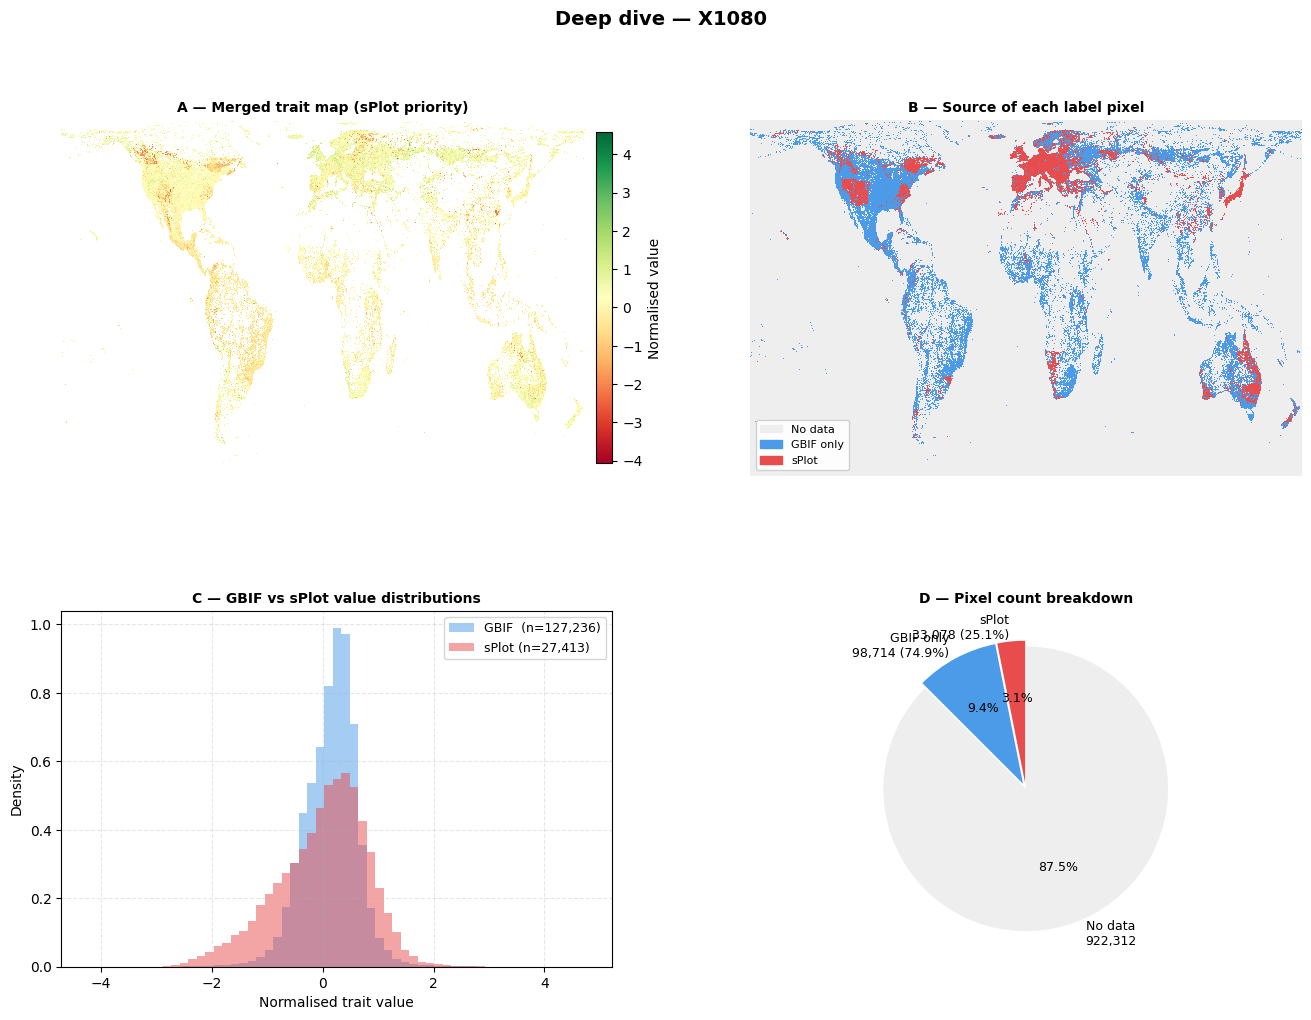

Saved: fig4_deep_dive_X1080.png


In [86]:
TRAIT = all_traits[0]   # ← change to any trait ID

merged_arr = load_tif(MERGED_DIR / f"{TRAIT}.tif")
source_arr = load_source_mask(TRAIT)
gbif_arr   = load_tif(GBIF_DIR  / f"{TRAIT}.tif") if (GBIF_DIR  / f"{TRAIT}.tif").exists() else np.full_like(merged_arr, np.nan)
splot_arr  = load_tif(SPLOT_DIR / f"{TRAIT}.tif") if (SPLOT_DIR / f"{TRAIT}.tif").exists() else np.full_like(merged_arr, np.nan)

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.25)
fig.suptitle(f"Deep dive — {TRAIT}", fontsize=14, fontweight="bold")

# Panel A: merged spatial map
ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(merged_arr, cmap="RdYlGn", interpolation="nearest", aspect="auto")
plt.colorbar(im0, ax=ax0, fraction=0.03, pad=0.02, label="Normalised value")
ax0.set_title("A — Merged trait map (sPlot priority)", fontsize=10, fontweight="bold")
ax0.axis("off")

# Panel B: source mask
ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(source_arr, cmap=SOURCE_CMAP, norm=SOURCE_NORM,
           interpolation="nearest", aspect="auto")
patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(SOURCE_COLORS, SOURCE_LABELS)]
ax1.legend(handles=patches, loc="lower left", fontsize=8, framealpha=0.9)
ax1.set_title("B — Source of each label pixel", fontsize=10, fontweight="bold")
ax1.axis("off")

# Panel C: histogram comparison
ax2 = fig.add_subplot(gs[1, 0])
valid_gbif  = gbif_arr[~np.isnan(gbif_arr)].ravel()
valid_splot = splot_arr[~np.isnan(splot_arr)].ravel()

all_vals = np.concatenate([v for v in [valid_gbif, valid_splot] if len(v) > 0])
bins     = np.linspace(all_vals.min() - 0.2, all_vals.max() + 0.2, 60)

if len(valid_gbif) > 0:
    ax2.hist(valid_gbif,  bins=bins, alpha=0.5, color="#4C9BE8",
             label=f"GBIF  (n={len(valid_gbif):,})",  density=True)
if len(valid_splot) > 0:
    ax2.hist(valid_splot, bins=bins, alpha=0.5, color="#E84C4C",
             label=f"sPlot (n={len(valid_splot):,})", density=True)
ax2.set_xlabel("Normalised trait value", fontsize=10)
ax2.set_ylabel("Density", fontsize=10)
ax2.set_title("C — GBIF vs sPlot value distributions", fontsize=10, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, linestyle="--")

# Panel D: source pie chart
ax3 = fig.add_subplot(gs[1, 1])
row    = summary_df[summary_df["trait"] == TRAIT].iloc[0]
sizes  = [row["n_splot"], row["n_gbif_only"], row["n_no_data"]]
labels = [
    f"sPlot\n{row['n_splot']:,} ({row['pct_splot']:.1f}%)",
    f"GBIF only\n{row['n_gbif_only']:,} ({row['pct_gbif_only']:.1f}%)",
    f"No data\n{row['n_no_data']:,}"
]
ax3.pie(sizes, labels=labels,
        colors=["#E84C4C", "#4C9BE8", "#EEEEEE"],
        explode=(0.04, 0.04, 0),
        autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
        startangle=90, textprops={"fontsize": 9})
ax3.set_title("D — Pixel count breakdown", fontsize=10, fontweight="bold")

plt.savefig(FIG_DIR / f"fig4_deep_dive_{TRAIT}.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: fig4_deep_dive_{TRAIT}.png")

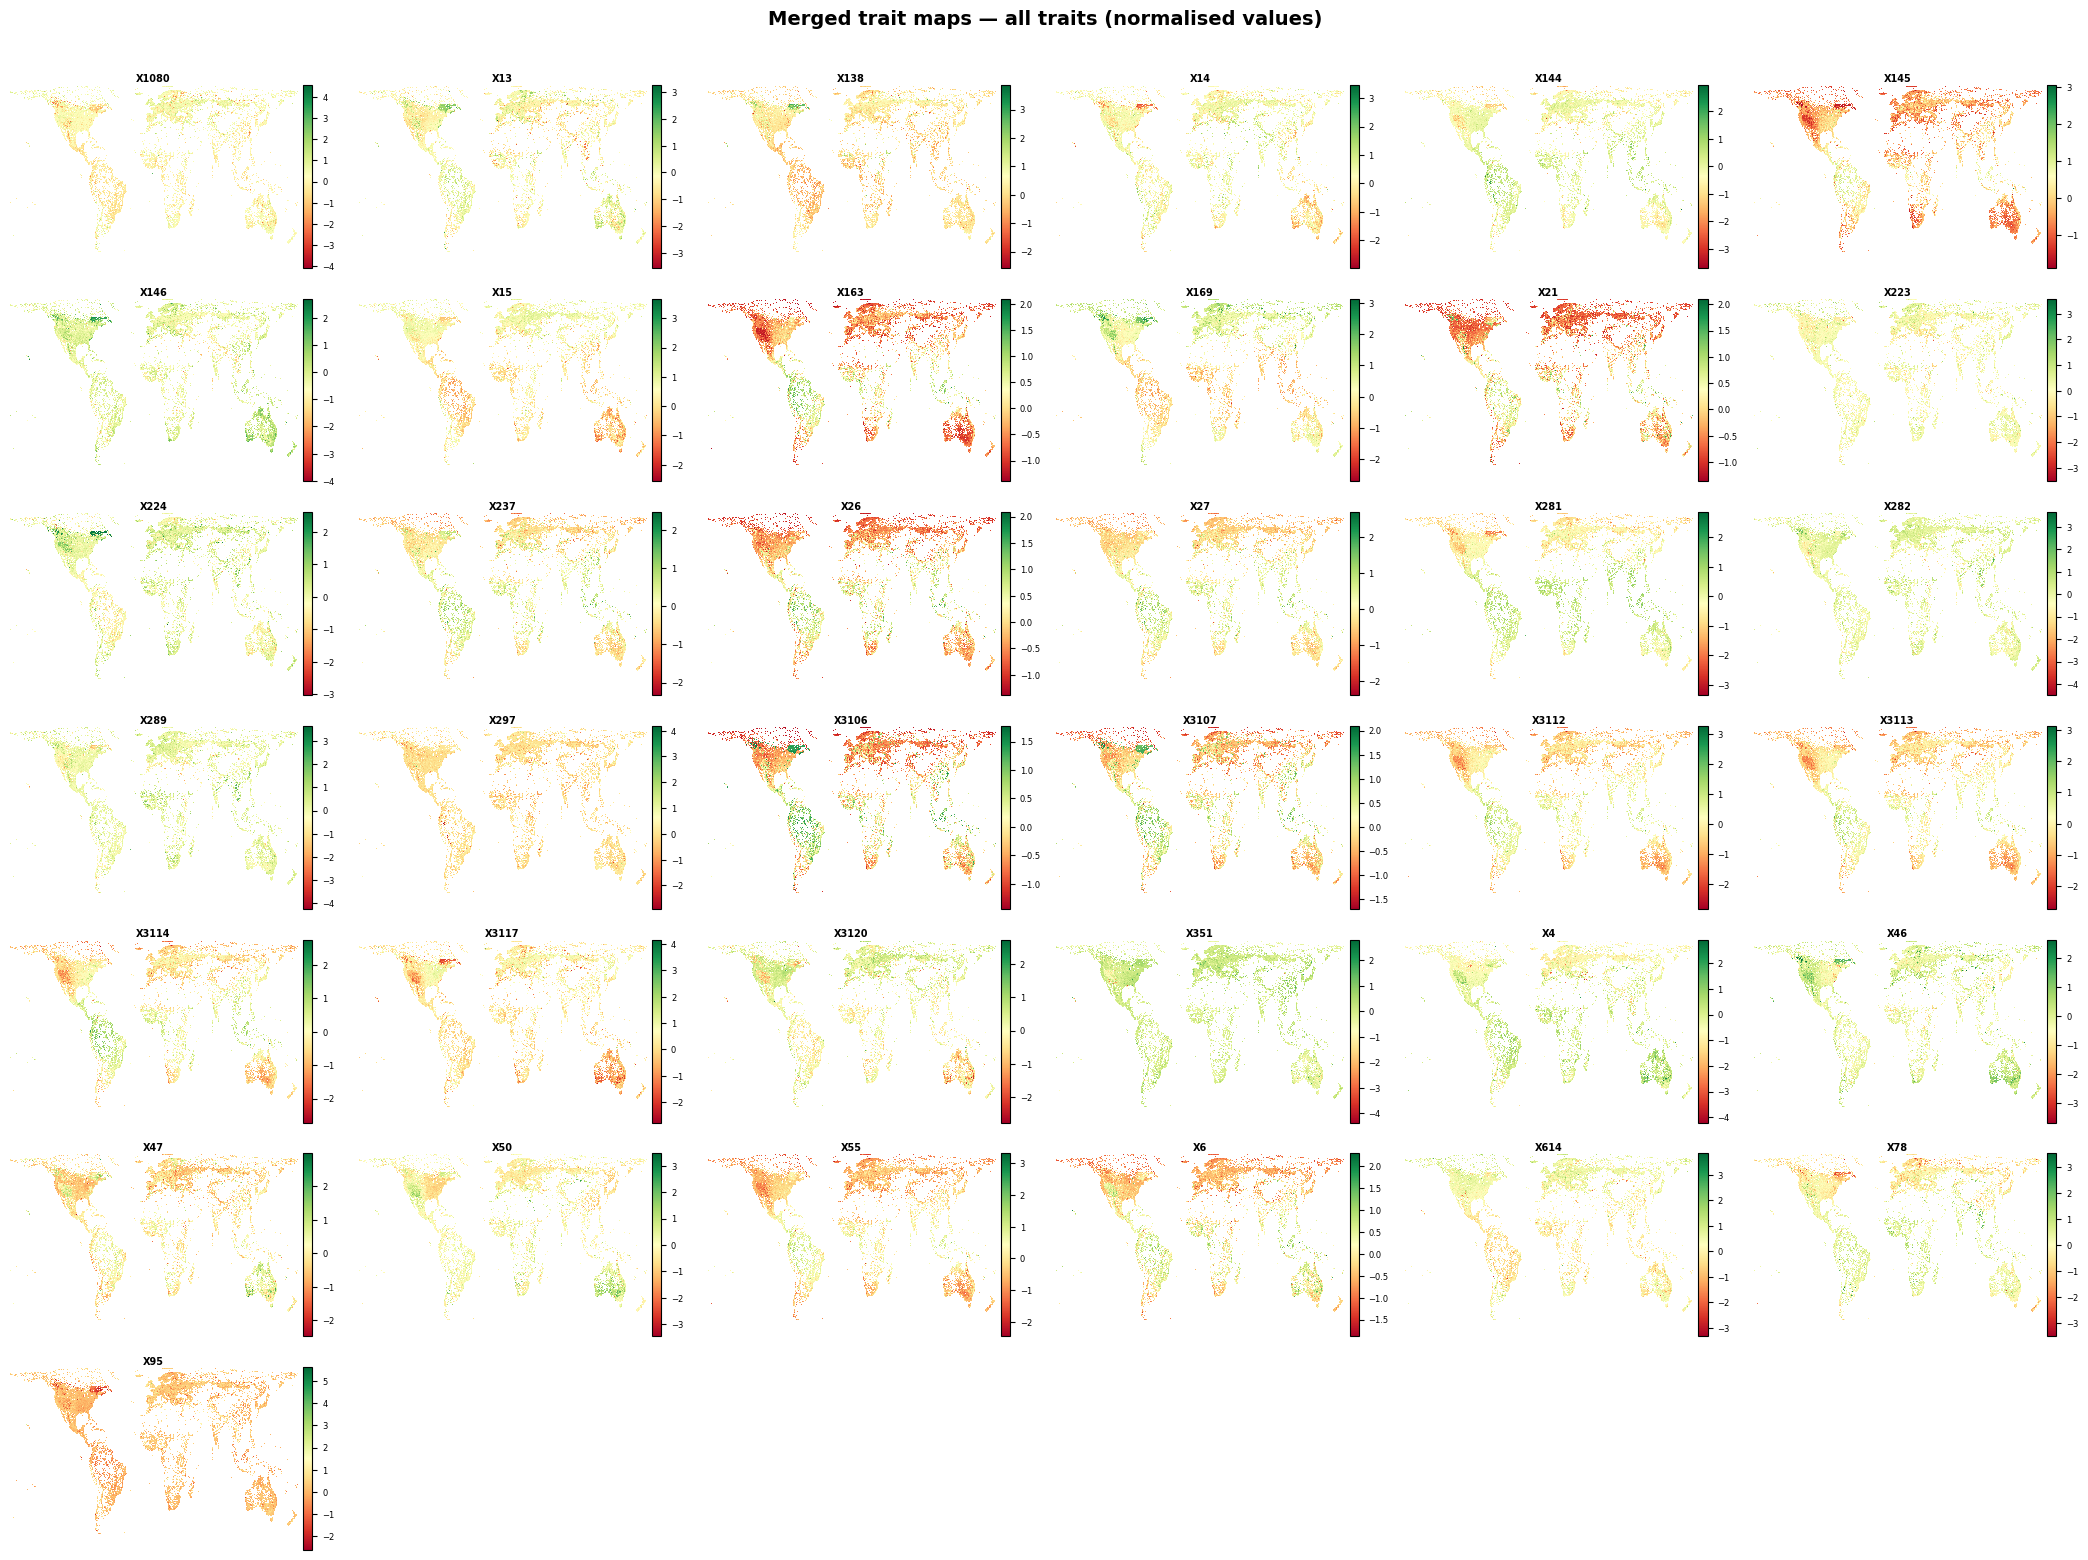

Saved: fig5_all_traits_grid.png


In [87]:
N     = len(all_traits)
ncols = 6
nrows = int(np.ceil(N / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.2))
fig.suptitle("Merged trait maps — all traits (normalised values)",
             fontsize=14, fontweight="bold", y=1.01)

for ax, trait in zip(axes.flat, all_traits):
    tif_path = MERGED_DIR / f"{trait}.tif"
    if not tif_path.exists():
        ax.set_visible(False)
        continue
    arr = load_tif(tif_path)
    im  = ax.imshow(arr, cmap="RdYlGn", interpolation="nearest", aspect="auto")
    ax.set_title(trait, fontsize=7, fontweight="bold", pad=2)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02).ax.tick_params(labelsize=6)

for ax in axes.flat[N:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_all_traits_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_all_traits_grid.png")

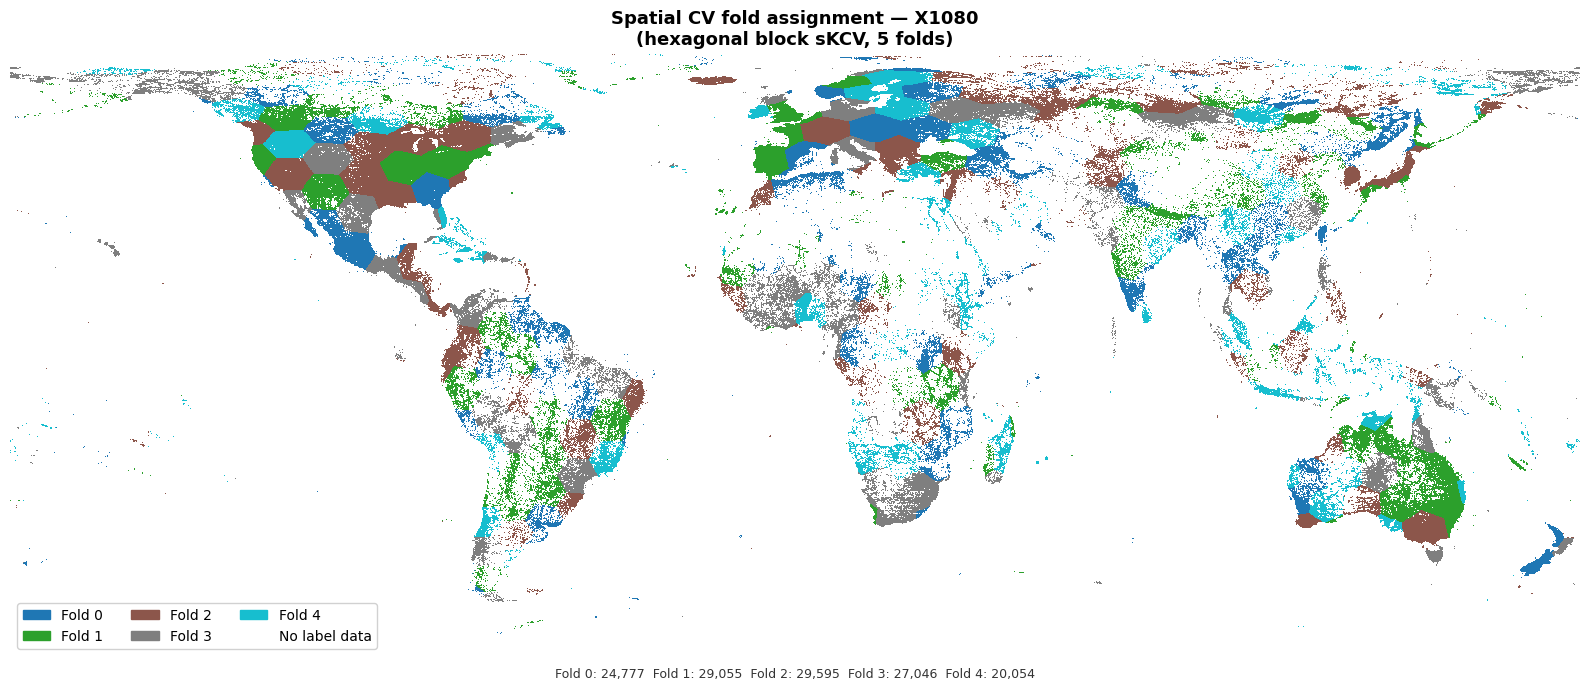

Saved: fig6_fold_coverage_X1080.png


In [88]:
example_trait = all_traits[0]
parquet_path  = SKCV_DIR / f"{example_trait}_mean.parquet"

splits_df = pd.read_parquet(parquet_path)  # columns: x, y, fold

with rasterio.open(MERGED_DIR / f"{example_trait}.tif") as src:
    transform = src.transform
    h, w      = src.height, src.width

fold_raster = np.full((h, w), np.nan, dtype=np.float32)
cols  = ((splits_df["x"] - transform.c) / transform.a).astype(int)
rows  = ((splits_df["y"] - transform.f) / transform.e).astype(int)
valid = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
fold_raster[rows[valid], cols[valid]] = splits_df["fold"].values[valid]

fig, ax   = plt.subplots(figsize=(16, 7))
cmap_fold = plt.cm.get_cmap("tab10", 5)
norm_fold = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 5)

ax.imshow(fold_raster, cmap=cmap_fold, norm=norm_fold,
          interpolation="nearest", aspect="auto")

fold_patches = [mpatches.Patch(color=cmap_fold(i), label=f"Fold {i}") for i in range(5)]
fold_patches.append(mpatches.Patch(color="white", label="No label data"))
ax.legend(handles=fold_patches, loc="lower left", fontsize=10,
          framealpha=0.9, ncol=3)
ax.set_title(f"Spatial CV fold assignment — {example_trait}\n"
             "(hexagonal block sKCV, 5 folds)",
             fontsize=13, fontweight="bold")
ax.axis("off")

fold_counts = splits_df["fold"].value_counts().sort_index()
count_str   = "  ".join([f"Fold {k}: {v:,}" for k, v in fold_counts.items()])
ax.text(0.5, -0.02, count_str, transform=ax.transAxes,
        ha="center", va="top", fontsize=9, color="#333333")

plt.tight_layout()
plt.savefig(FIG_DIR / f"fig6_fold_coverage_{example_trait}.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: fig6_fold_coverage_{example_trait}.png")

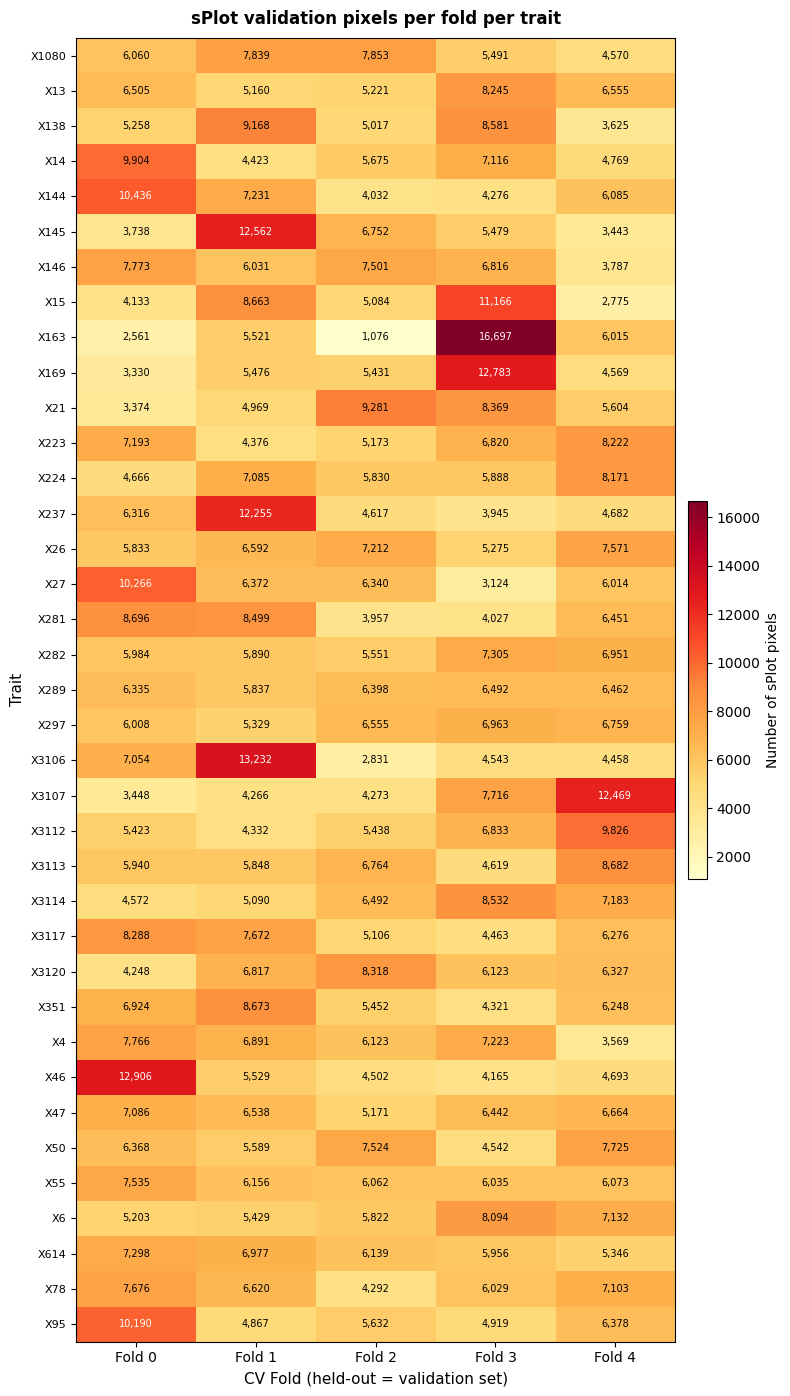

Saved: fig7_splot_per_fold_heatmap.png


In [89]:
fold_cols    = [c for c in fold_df.columns if c.startswith("fold_")]
heatmap_data = fold_df.set_index("trait")[fold_cols].copy()
heatmap_data.columns = [f"Fold {i}" for i in range(len(fold_cols))]

fig, ax = plt.subplots(figsize=(8, max(6, len(heatmap_data) * 0.38)))

im = ax.imshow(heatmap_data.values, cmap="YlOrRd", aspect="auto")

for i in range(len(heatmap_data)):
    for j in range(len(fold_cols)):
        val        = heatmap_data.values[i, j]
        text_color = "white" if val > heatmap_data.values.max() * 0.6 else "black"
        ax.text(j, i, f"{val:,}", ha="center", va="center",
                fontsize=7, color=text_color)

ax.set_xticks(range(len(fold_cols)))
ax.set_xticklabels(heatmap_data.columns, fontsize=10)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)
ax.set_xlabel("CV Fold (held-out = validation set)", fontsize=11)
ax.set_ylabel("Trait", fontsize=11)
ax.set_title("sPlot validation pixels per fold per trait",
             fontsize=12, fontweight="bold", pad=10)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Number of sPlot pixels")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_splot_per_fold_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig7_splot_per_fold_heatmap.png")